# COEP Technological University
## Artificial Intelligence - Lab Assignment 3
### Machine Learning Classification

**Name**: Arnav Singhal\
**MIS**: 612203012\
**Div**: 1 | **Batch**: T3

## 1. Introduction

**Dataset:** AHS-CAB 2014, Madhya Pradesh, Indore (data.gov.in)

**Problem Statement:** Classify individual health survey respondents as living in a **Rural** or **Urban** area using physiological measurements and demographic attributes from the Annual Health Survey (AHS-CAB 2014), Indore district, Madhya Pradesh - sourced from India's government open-data portal (data.gov.in).

**Reasons for choosing this dataset:**
- Real government data from data.gov.in
- 8,750 records (> 500 required)
- 8 meaningful features across numerical and categorical types
- Clear binary target (`rural_urban`)
- Class imbalance (~2.5:1 Urban:Rural), missing values (30–40% in some columns)

## 2. Imports & Setup

All required libraries are imported here. Warnings are suppressed to keep the output clean.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    StratifiedKFold, cross_val_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
import joblib
from collections import Counter

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
print('All libraries loaded successfully.')

All libraries loaded successfully.


## 3. Data Acquisition & Loading

The dataset is the Annual Health Survey (AHS-CAB 2014) for Madhya Pradesh, Indore district, sourced from the Indian government open-data portal (data.gov.in). It contains individual-level health survey records with physiological measurements and demographic attributes.

In [2]:
df = pd.read_csv('ahs-cab2014-madhya_pradesh-indore.csv')
print('=> df.head()')
display(df.head())

print('\n=> df.shape')
print(df.shape)

print('\n=> df.info()')
df.info()

=> df.head()


,state_code,district_code,rural_urban,stratum,PSU_ID,ahs_house_unit,house_hold_no,date_survey,test_salt_iodine,record_code_iodine,...,day_or_mn_for_breast_feeding_cd,day_or_month_for_breast_feeding,water_month,ani_milk_month,semisolid_month_or_day,solid_month,vegetables_month_or_day,illness_type,illness_duration,treatment_type
0,MADHYA PRADESH,INDORE,Rural,population>=2000,1881531,51,1,01/10/2014,7,Less than 15 PPM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MADHYA PRADESH,INDORE,Rural,population>=2000,1881527,215,1,18/07/2014,30,More than or equal to 15 PPM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MADHYA PRADESH,INDORE,Rural,population>=2000,1881528,274,1,19/07/2014,30,More than or equal to 15 PPM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MADHYA PRADESH,INDORE,Rural,population>=2000,1881529,408,1,01/05/2014,30,More than or equal to 15 PPM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MADHYA PRADESH,INDORE,Rural,population>=2000,1881530,447,1,05/09/2014,30,More than or equal to 15 PPM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=> df.shape
(8750, 53)

=> df.info()
<class 'pandas.DataFrame'>
RangeIndex: 8750 entries, 0 to 8749
Data columns (total 53 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   state_code                       8750 non-null   str    
 1   district_code                    8750 non-null   str    
 2   rural_urban                      8750 non-null   str    
 3   stratum                          8750 non-null   str    
 4   PSU_ID                           8750 non-null   int64  
 5   ahs_house_unit                   8750 non-null   int64  
 6   house_hold_no                    8750 non-null   int64  
 7   date_survey                      8750 non-null   str    
 8   test_salt_iodine                 8750 non-null   int64  
 9   record_code_iodine               8750 non-null   str    
 10  record_code_iodine_reason        0 non-null      float64
 11  sl_no                            8750 non-null   int64 

In [3]:
print('Class Distribution:')
print(df['rural_urban'].value_counts())
print('\nClass Proportions:')
print(df['rural_urban'].value_counts(normalize=True).round(3))

Class Distribution:
rural_urban
Urban    6282
Rural    2468
Name: count, dtype: int64

Class Proportions:
rural_urban
Urban    0.718
Rural    0.282
Name: proportion, dtype: float64


## 4. Manual Feature Selection

Ten numerical health features and three categorical features are selected as predictors based on domain knowledge. `Age` and `Age_Code` are combined into a single `Age_years` feature (converting month-coded ages to years) before model training. All other columns are dropped to keep the feature space focused and clinically interpretable.


In [4]:
FEATURES_NUM = [
    'Age',
    'Weight_in_kg', 
    'Length_height_cm', 
    'BP_systolic', 
    'BP_Diastolic', 
    'Pulse_rate', 
    'fasting_blood_glucose_mg_dl',
    'test_salt_iodine',
    'ahs_house_unit',
    'house_hold_no'
]

FEATURES_CAT = [
    'Sex', 
    'Haemoglobin_test',
    'Age_Code'
]

TARGET = 'rural_urban'

cols = FEATURES_NUM + FEATURES_CAT + [TARGET]
df = df[cols].copy()

print('Selected shape:', df.shape)
print('\nMissing values (%):')
print((df.isnull().mean() * 100).round(1))


Selected shape: (8750, 14)

Missing values (%):
Age                             0.0
Weight_in_kg                    5.2
Length_height_cm                5.2
BP_systolic                    30.7
BP_Diastolic                   30.7
Pulse_rate                     30.7
fasting_blood_glucose_mg_dl    40.0
test_salt_iodine                0.0
ahs_house_unit                  0.0
house_hold_no                   0.0
Sex                             0.0
Haemoglobin_test                1.1
Age_Code                        0.0
rural_urban                     0.0
dtype: float64


## 5. Preprocessing & Feature Engineering

The raw data requires cleaning before it can be used for modelling. Each subsection below addresses one stage of the pipeline.

### 5.1 Missing Value Imputation

Numerical features are imputed with the column median, which is robust to the skewed distributions common in physiological measurements. The categorical Sex column is imputed with the most frequent value.

In [5]:
num_imp = SimpleImputer(strategy='median')
df[FEATURES_NUM] = num_imp.fit_transform(df[FEATURES_NUM])

cat_imp = SimpleImputer(strategy='most_frequent')
df[FEATURES_CAT] = cat_imp.fit_transform(df[FEATURES_CAT])

df['Age_years'] = df.apply(
    lambda row: row['Age'] / 12 if row['Age_Code'] == "Months" else row['Age'],
    axis=1
)
df.drop(columns=['Age', 'Age_Code'], inplace=True)

FEATURES_NUM = [c for c in FEATURES_NUM if c != 'Age'] + ['Age_years']
FEATURES_CAT = [c for c in FEATURES_CAT if c != 'Age_Code']

print('Missing values after imputation:')
print(df.isnull().sum())


Missing values after imputation:
Weight_in_kg                   0
Length_height_cm               0
BP_systolic                    0
BP_Diastolic                   0
Pulse_rate                     0
fasting_blood_glucose_mg_dl    0
test_salt_iodine               0
ahs_house_unit                 0
house_hold_no                  0
Sex                            0
Haemoglobin_test               0
rural_urban                    0
Age_years                      0
dtype: int64


### 5.2 Outlier Handling (IQR Capping)

Feature values beyond 1.5 times the interquartile range are clipped to the boundary. This reduces the influence of data entry errors and extreme physiological readings. The derived `Age_years` column is included in capping alongside the original numeric features.


In [6]:
Q1 = df[FEATURES_NUM].quantile(0.25)
Q3 = df[FEATURES_NUM].quantile(0.75)
IQR = Q3 - Q1

df[FEATURES_NUM] = df[FEATURES_NUM].clip(
    lower=Q1 - 1.5 * IQR,
    upper=Q3 + 1.5 * IQR,
    axis=1
)
print("Outliers capped using IQR method.")
print(df[FEATURES_NUM].describe().round(2))


Outliers capped using IQR method.
       Weight_in_kg  Length_height_cm  BP_systolic  BP_Diastolic  Pulse_rate  \
count       8750.00           8750.00      8750.00       8750.00     8750.00   
mean          38.63            131.48       126.56         77.12       76.95   
std           21.73             38.38        13.48         10.76        9.70   
min            1.00             49.50       100.00         49.00       60.00   
25%           16.13            106.52       121.00         70.00       70.00   
50%           45.60            150.00       127.00         77.00       77.00   
75%           53.80            158.20       135.00         84.00       81.00   
max          110.31            193.30       156.00        105.00       97.50   

       fasting_blood_glucose_mg_dl  test_salt_iodine  ahs_house_unit  \
count                      8750.00            8750.0         8750.00   
mean                         92.67              30.0          194.08   
std                          

### 5.3 Encoding

The `Sex` column has two unique values so it is one-hot encoded with `drop_first=True`, producing a single binary column `Sex_Male`. The categorical `Haemoglobin_test` column is similarly one-hot encoded. The target variable `rural_urban` is label-encoded to integers for compatibility with all classifiers. Note: `Age` and `Age_Code` have already been merged into the numeric `Age_years` feature in the previous step and are no longer present.


In [7]:
df = pd.get_dummies(df, columns=FEATURES_CAT, drop_first=True)
print('Columns after OHE:', df.columns.tolist())

le = LabelEncoder()
df[TARGET] = le.fit_transform(df[TARGET])
print('\nClasses (integer → label):', dict(enumerate(le.classes_)))
print('\nEncoded class distribution:')
print(pd.Series(df[TARGET]).value_counts())

Columns after OHE: ['Weight_in_kg', 'Length_height_cm', 'BP_systolic', 'BP_Diastolic', 'Pulse_rate', 'fasting_blood_glucose_mg_dl', 'test_salt_iodine', 'ahs_house_unit', 'house_hold_no', 'rural_urban', 'Age_years', 'Sex_Male', 'Haemoglobin_test_YES']

Classes (integer → label): {0: 'Rural', 1: 'Urban'}

Encoded class distribution:
rural_urban
1    6282
0    2468
Name: count, dtype: int64


### 5.4 Feature Scaling & Selection

StandardScaler is applied so that distance-based models such as SVM and KNN are not dominated by features with large magnitudes. SelectKBest with the ANOVA F-test then retains the 8 features most statistically associated with the target.

In [8]:
FEATURE_COLS = [c for c in df.columns if c != TARGET]
X = df[FEATURE_COLS]
y = df[TARGET]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

selector = SelectKBest(score_func=f_classif, k=min(8, len(FEATURE_COLS)))
X_selected = selector.fit_transform(X_scaled, y)

selected_features = np.array(FEATURE_COLS)[selector.get_support()].tolist()
print('Top selected features:', selected_features)
print('X_selected shape:', X_selected.shape)

Top selected features: ['Weight_in_kg', 'Length_height_cm', 'BP_systolic', 'BP_Diastolic', 'Pulse_rate', 'ahs_house_unit', 'Age_years', 'Haemoglobin_test_YES']
X_selected shape: (8750, 8)


## 6. Exploratory Data Analysis (EDA)

Four plots are produced to understand the class balance, feature distributions, and inter-feature relationships before training.

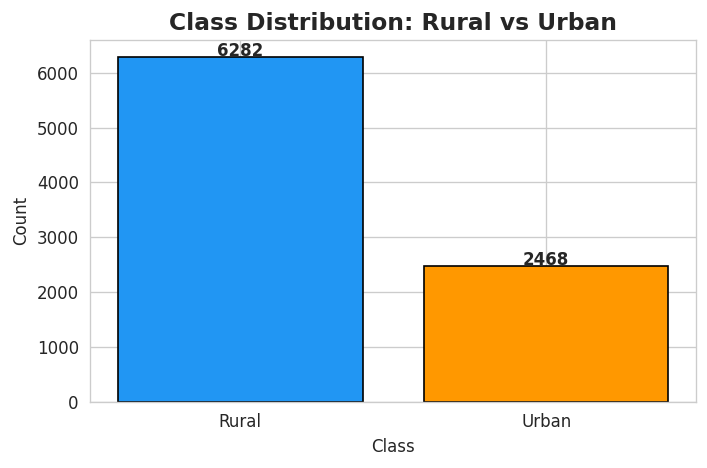

Class distribution saved.


In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df[TARGET].value_counts()
ax.bar(le.classes_, counts.values, color=['#2196F3', '#FF9800'], edgecolor='black')
ax.set_title('Class Distribution: Rural vs Urban', fontsize=14, fontweight='bold')
ax.set_xlabel('Class'); ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('class_dist.png', dpi=150)
plt.show()
print("Class distribution saved.")


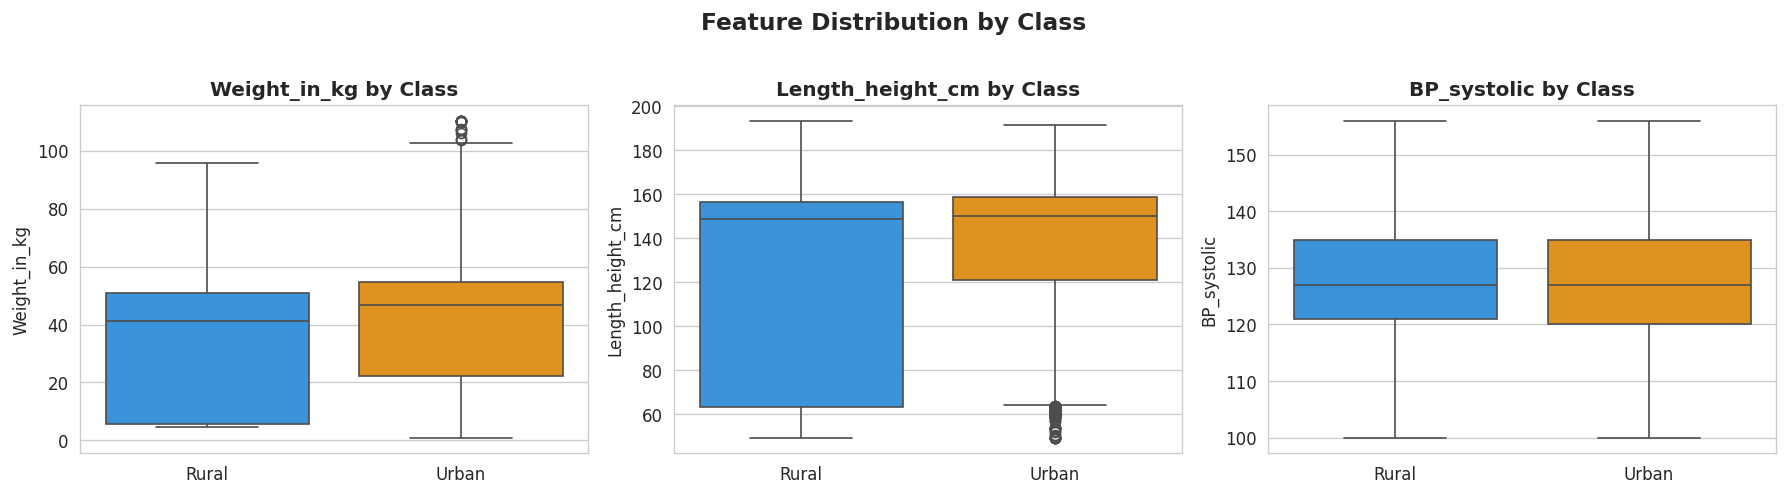

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df_plot = df.copy()
df_plot['Class'] = le.inverse_transform(df_plot[TARGET])

for ax, feat in zip(axes, selected_features[:3]):
    if feat in df_plot.columns:
        sns.boxplot(x='Class', y=feat, data=df_plot, ax=ax,
                    palette=['#2196F3', '#FF9800'])
        ax.set_title(f'{feat} by Class', fontweight='bold')
        ax.set_xlabel(''); ax.set_ylabel(feat)

plt.suptitle('Feature Distribution by Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


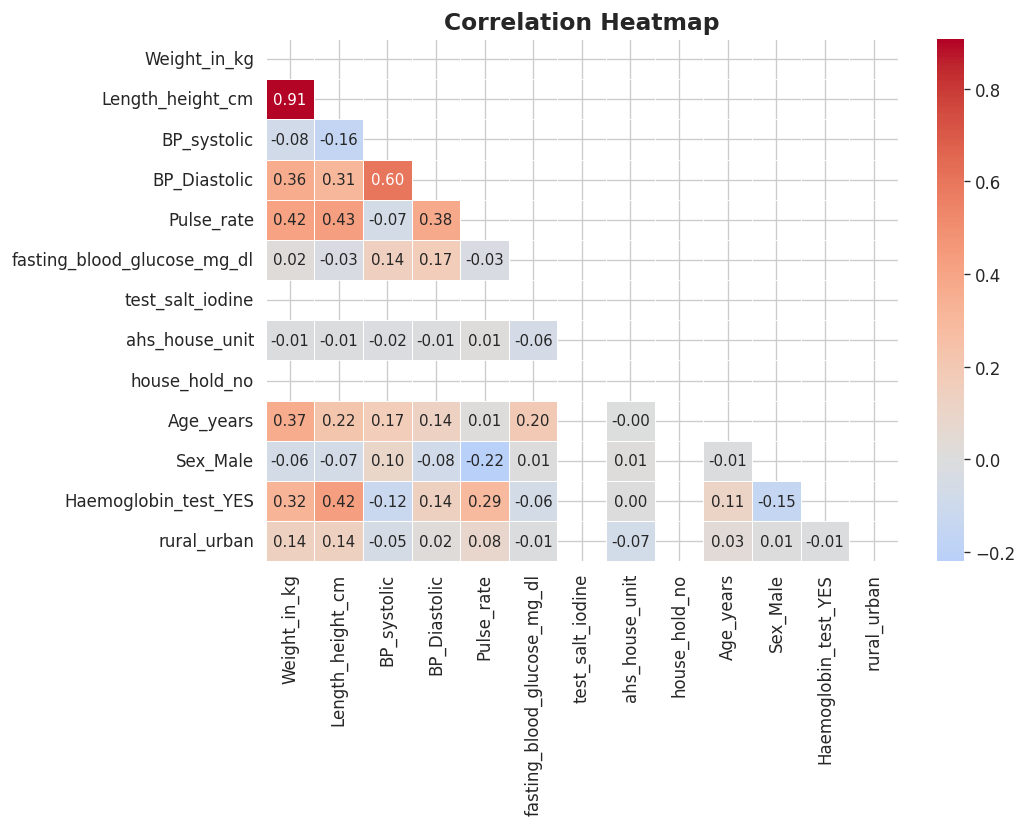

In [11]:
plt.figure(figsize=(9, 7))
corr = df[FEATURE_COLS + [TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('corr.png', dpi=150)
plt.show()


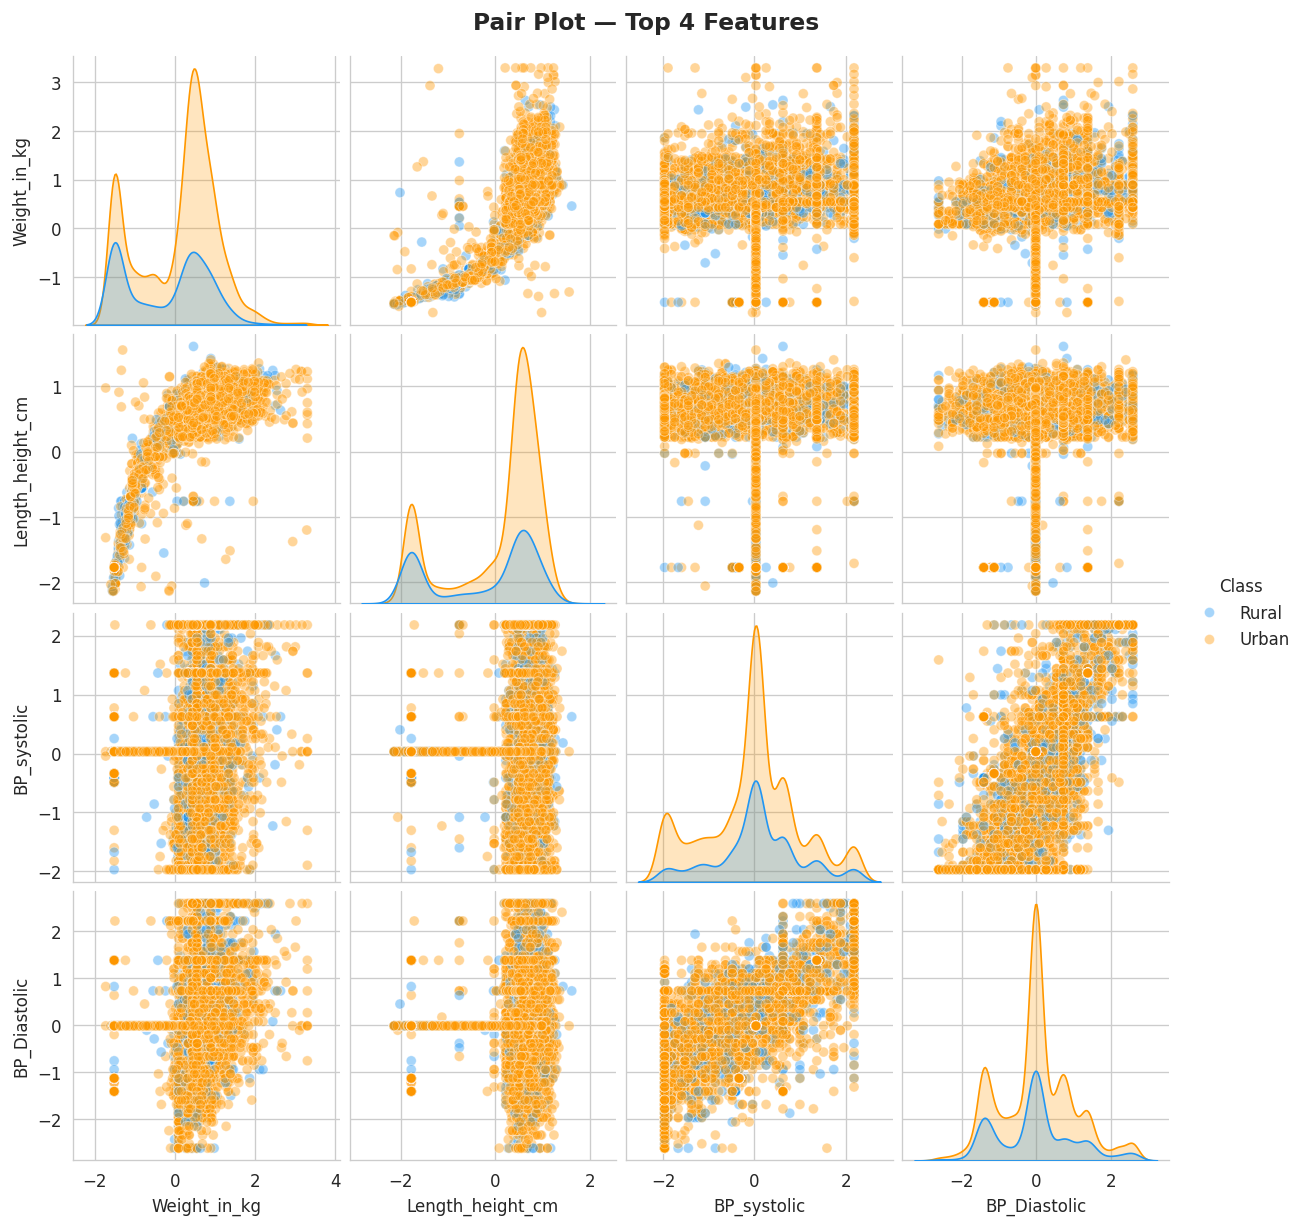

In [12]:
df_pair = pd.DataFrame(X_scaled, columns=FEATURE_COLS)
df_pair[TARGET] = df[TARGET].values
df_pair['Class'] = le.inverse_transform(df_pair[TARGET].astype(int))

pair_feats = selected_features[:4]
g = sns.pairplot(df_pair[pair_feats + ['Class']], hue='Class',
                 diag_kind='kde', plot_kws={'alpha': 0.4},
                 palette=['#2196F3', '#FF9800'])
g.figure.suptitle('Pair Plot — Top 4 Features', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('pairplot.png', dpi=120, bbox_inches='tight')
plt.show()


## 7. Model Training

Four classifiers are trained and compared. Each model receives the same scaled, selected feature matrix.

### 7.1 Stratified Train-Test Split

80% of the data is used for training and 20% is held out as the test set. Stratification ensures that the Rural-to-Urban class ratio is preserved in both splits.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.20,
    random_state=42, stratify=y
)

print(f"Train set: {X_train.shape}")
print(f"Test set:  {X_test.shape}")
print(f"\nTrain class proportions: {np.bincount(y_train) / len(y_train)}")
print(f"Test  class proportions: {np.bincount(y_test)  / len(y_test)}")


Train set: (7000, 8)
Test set:  (1750, 8)

Train class proportions: [0.282 0.718]
Test  class proportions: [0.28228571 0.71771429]


### 7.2 Train All Four Classifiers

Logistic Regression serves as the linear baseline. SVM with an RBF kernel captures non-linear decision boundaries. Decision Tree offers interpretability for health policy analysis, and KNN classifies based on neighbourhood similarity.

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'SVM':                 SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=7),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'{name} trained.')

Logistic Regression trained.
SVM trained.
Decision Tree trained.
KNN trained.


## 8. Evaluation & Metrics

Each model is evaluated on five metrics: Accuracy, Precision, Recall, F1-score, and ROC-AUC. F1-score is the primary criterion because the dataset has a class imbalance of approximately 2.5:1 (Urban to Rural).

In [15]:
results = {}

for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted')
    f1   = f1_score(y_test, y_pred, average='weighted')
    auc  = roc_auc_score(y_test, y_proba)

    results[name] = {'Accuracy': acc, 'Precision': prec,
                     'Recall': rec, 'F1': f1, 'ROC-AUC': auc}

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))



  Logistic Regression
              precision    recall  f1-score   support

       Rural       0.37      0.59      0.46       494
       Urban       0.79      0.61      0.69      1256

    accuracy                           0.60      1750
   macro avg       0.58      0.60      0.57      1750
weighted avg       0.67      0.60      0.62      1750


  SVM
              precision    recall  f1-score   support

       Rural       0.42      0.59      0.49       494
       Urban       0.81      0.68      0.74      1256

    accuracy                           0.66      1750
   macro avg       0.62      0.64      0.62      1750
weighted avg       0.70      0.66      0.67      1750


  Decision Tree
              precision    recall  f1-score   support

       Rural       0.36      0.75      0.49       494
       Urban       0.83      0.48      0.61      1256

    accuracy                           0.55      1750
   macro avg       0.59      0.61      0.55      1750
weighted avg       0.70    

### 8.1 Model Comparison Table

The table below summarises test-set metrics for all four models. The best model by F1-score is identified.

In [16]:
results_df = pd.DataFrame(results).T.round(4)
print("\n=> Model Comparison")
print(results_df.to_string())

best_model_name = results_df['F1'].idxmax()
print(f"\nBest model by F1-score: {best_model_name} ({results_df.loc[best_model_name,'F1']:.4f})")



=> Model Comparison
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.6040     0.6725  0.6040  0.6230   0.6296
SVM                    0.6554     0.7000  0.6554  0.6696   0.6903
Decision Tree          0.5543     0.6959  0.5543  0.5725   0.6586
KNN                    0.7211     0.6905  0.7211  0.6935   0.6664

Best model by F1-score: KNN (0.6935)


### 8.2 Confusion Matrices

A confusion matrix shows the counts of true positives, true negatives, false positives, and false negatives for each model. This reveals whether a model systematically misclassifies one class over the other.

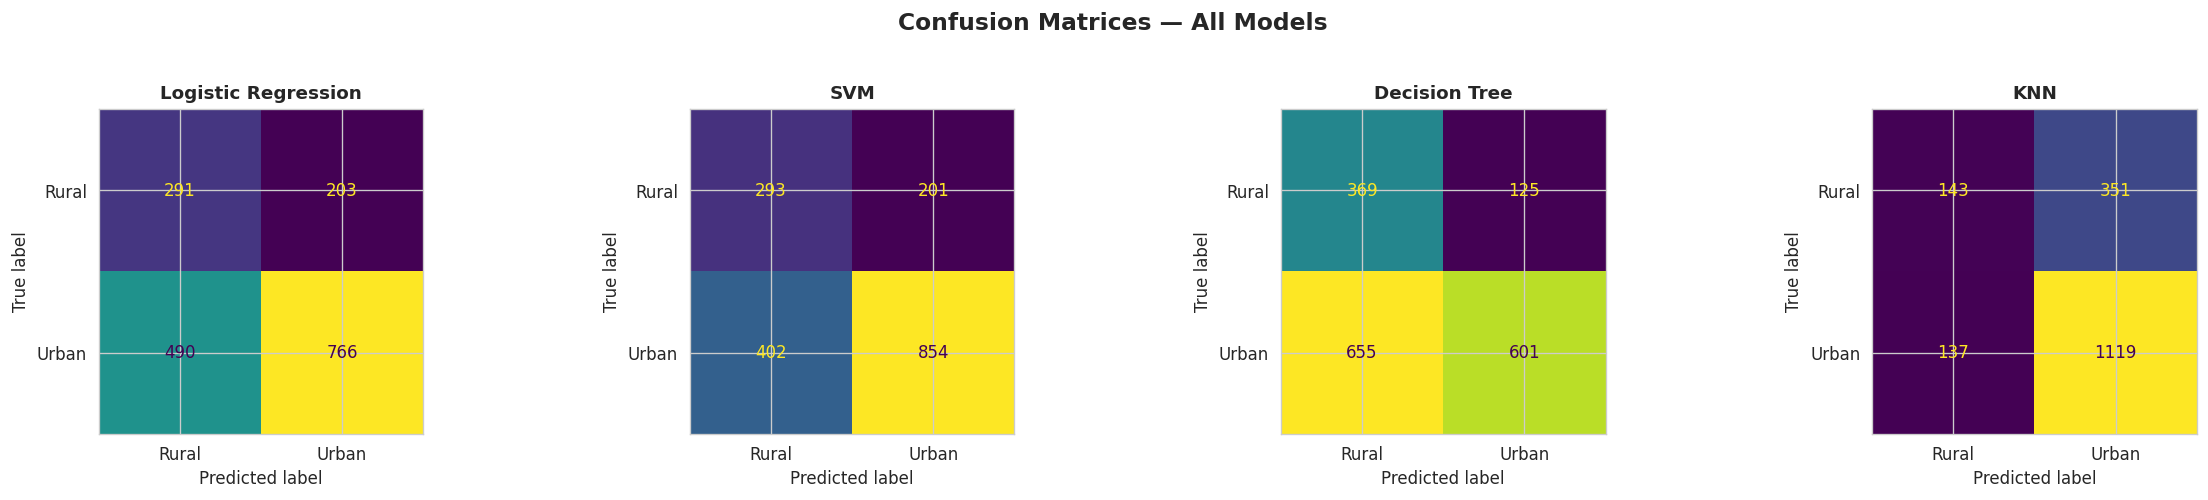

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, colorbar=False)
    ax.set_title(name, fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


### 8.3 ROC Curves

The ROC curve plots the true positive rate against the false positive rate at various classification thresholds. A higher area under the curve (AUC) indicates a better-performing model.

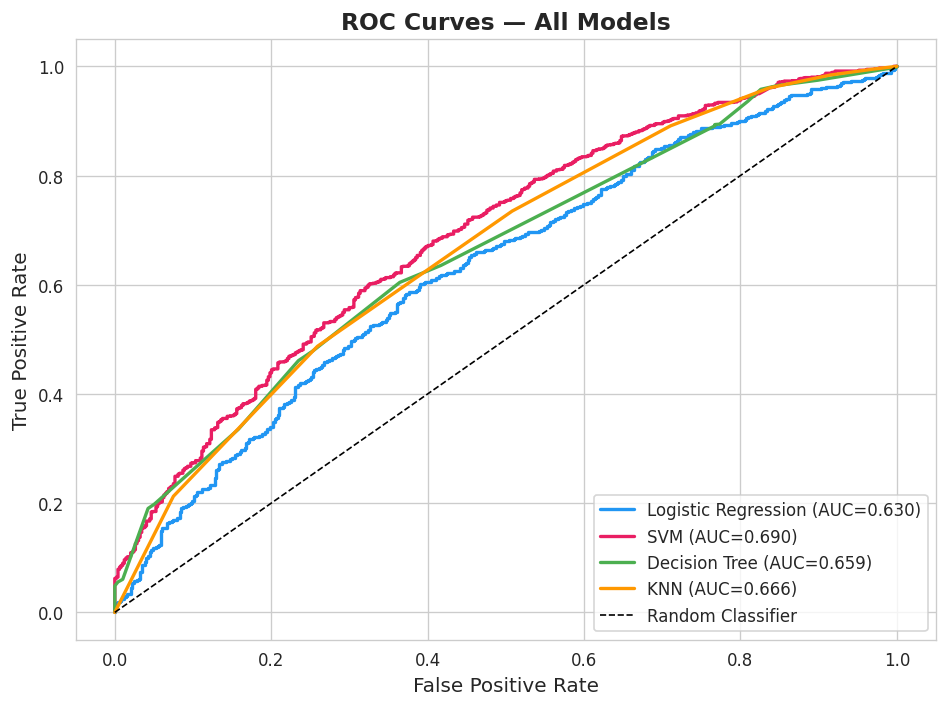

In [18]:
plt.figure(figsize=(8, 6))
colors = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800']

for (name, model), color in zip(models.items(), colors):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()


### 8.4 Metric Comparison Bar Chart

A grouped bar chart compares all five metrics across all four models in a single view.

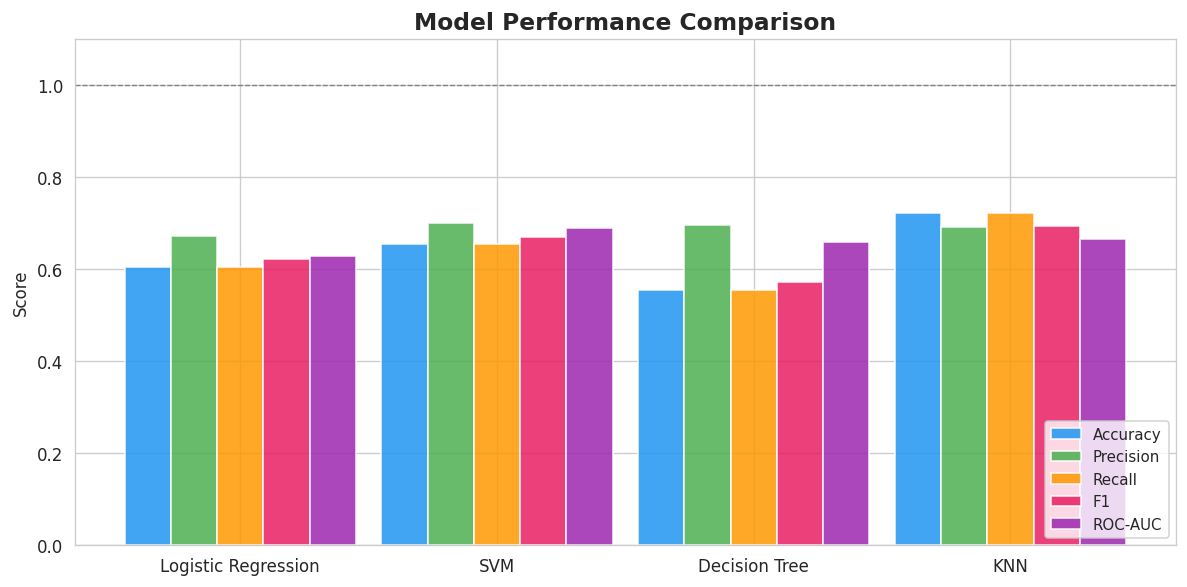

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
w = 0.18
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
colors_bar = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']

for i, (metric, color) in enumerate(zip(metrics, colors_bar)):
    ax.bar(x + i*w, results_df[metric], w, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + w*2)
ax.set_xticklabels(results_df.index, fontsize=10)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.1)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.axhline(y=1.0, color='gray', linestyle='--', lw=0.8)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()


## 9. Hyperparameter Tuning (Grid Search)

5-fold cross-validated grid search is used to find the best hyperparameters for the Decision Tree and KNN classifiers. The search maximises weighted F1-score, which accounts for class imbalance.

In [20]:
dt_params = {
    'max_depth':        [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion':        ['gini', 'entropy']
}
dt_gs = GridSearchCV(DecisionTreeClassifier(random_state=42, class_weight='balanced'),
                     dt_params, cv=5, scoring='f1_weighted', n_jobs=-1)
dt_gs.fit(X_train, y_train)
print("Best Decision Tree params:", dt_gs.best_params_)
print(f"Best DT CV F1: {dt_gs.best_score_:.4f}")


Best Decision Tree params: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
Best DT CV F1: 0.6846


In [21]:
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}
knn_gs = GridSearchCV(KNeighborsClassifier(),
                      knn_params, cv=5, scoring='f1_weighted', n_jobs=-1)
knn_gs.fit(X_train, y_train)
print("Best KNN params:", knn_gs.best_params_)
print(f"Best KNN CV F1: {knn_gs.best_score_:.4f}")


Best KNN params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
Best KNN CV F1: 0.6990


## 10. Stratified Cross-Validation

5-fold stratified cross-validation is run on the full selected feature matrix. Stratification ensures each fold preserves the class ratio, giving a reliable estimate of generalisation performance.

In [22]:
models['Decision Tree'] = dt_gs.best_estimator_
models['KNN'] = knn_gs.best_estimator_
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n=> 5-Fold Stratified Cross-Validation (F1 Weighted)")
cv_results = {}
for name, model in models.items():
    cv_f1 = cross_val_score(model, X_selected, y, cv=skf, scoring='f1_weighted')
    cv_results[name] = cv_f1
    print(f"{name:25s}: Mean={cv_f1.mean():.4f}  Std={cv_f1.std():.4f}")



=> 5-Fold Stratified Cross-Validation (F1 Weighted)
Logistic Regression      : Mean=0.6031  Std=0.0152
SVM                      : Mean=0.6600  Std=0.0106
Decision Tree            : Mean=0.6866  Std=0.0109
KNN                      : Mean=0.6985  Std=0.0088


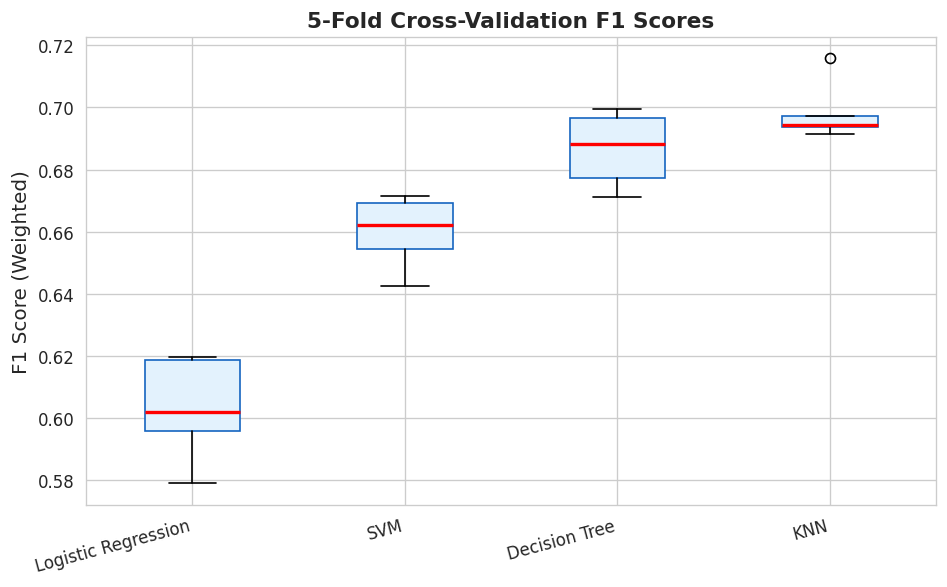

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
           boxprops=dict(facecolor='#E3F2FD', color='#1565C0'),
           medianprops=dict(color='red', lw=2))
ax.set_ylabel('F1 Score (Weighted)', fontsize=12)
ax.set_title('5-Fold Cross-Validation F1 Scores', fontsize=13, fontweight='bold')
ax.set_xticklabels(cv_results.keys(), rotation=15, ha='right')
plt.tight_layout()
plt.savefig('cv_boxplot.png', dpi=150)
plt.show()


## 11. Decision Tree Visualisation

The tuned Decision Tree is visualised to a depth of 3 levels. This makes the model interpretable by showing which features and thresholds drive the Rural vs Urban classification.

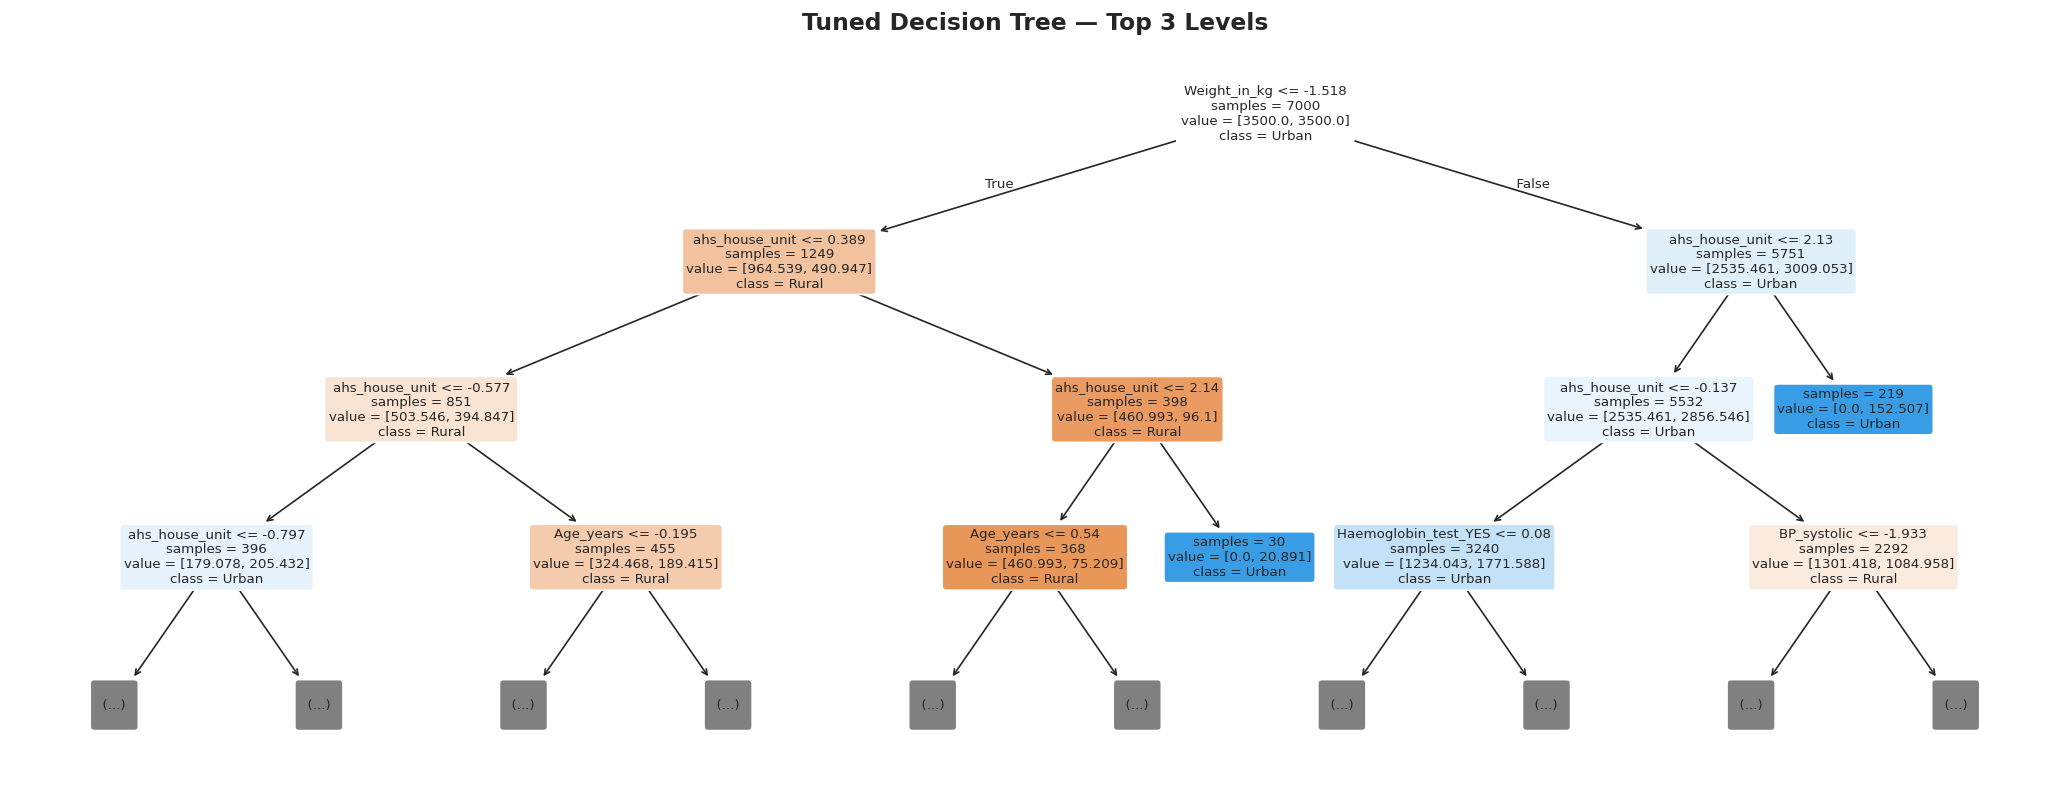

Decision tree visualisation saved.


In [24]:
best_dt = dt_gs.best_estimator_
plt.figure(figsize=(22, 8))
plot_tree(best_dt,
          feature_names=selected_features,
          class_names=le.classes_,
          filled=True, fontsize=8, max_depth=3,
          rounded=True, impurity=False)
plt.title('Tuned Decision Tree — Top 3 Levels', fontsize=14, fontweight='bold')
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("Decision tree visualisation saved.")


## 12. Model Serialisation

The best model and all preprocessing objects are saved to disk for use in a REST API. Five artefacts are serialised: the classifier, scaler, selector, label encoder, and numerical imputer.

In [25]:
best_model_name = results_df['F1'].idxmax()
print(f"Selecting best model: {best_model_name}")

y_pred_tuned_dt = dt_gs.best_estimator_.predict(X_test)
f1_tuned_dt = f1_score(y_test, y_pred_tuned_dt, average='weighted')
print(f"Tuned DT test F1: {f1_tuned_dt:.4f}")

best_model = models[best_model_name]

joblib.dump(best_model, 'classifier_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
joblib.dump(selector,   'selector.pkl')
joblib.dump(le,         'label_encoder.pkl')
joblib.dump(num_imp,    'num_imputer.pkl')

print("\nAll pipeline components saved:")
print("classifier_model.pkl, scaler.pkl, selector.pkl, label_encoder.pkl, num_imputer.pkl")


Selecting best model: KNN
Tuned DT test F1: 0.6878

All pipeline components saved:
classifier_model.pkl, scaler.pkl, selector.pkl, label_encoder.pkl, num_imputer.pkl


## 13. Prediction Drift Monitoring

A class-distribution drift monitor is implemented. It compares the proportion of Rural and Urban predictions on new data against the training baseline and raises an alert if any class shifts by more than 10 percentage points.

In [26]:
train_preds = best_model.predict(X_train)
baseline_dist  = Counter(le.inverse_transform(train_preds))
baseline_total = sum(baseline_dist.values())
baseline_pct   = {k: v / baseline_total for k, v in baseline_dist.items()}

print("Baseline class proportions (training):")
for cls, pct in baseline_pct.items():
    print(f"  {cls}: {pct:.3%}")

def check_prediction_drift(new_predictions, threshold=0.10):
    new_dist  = Counter(le.inverse_transform(new_predictions))
    new_total = sum(new_dist.values())
    new_pct   = {k: new_dist.get(k, 0) / new_total for k in baseline_pct}

    drift_detected = False
    for cls in baseline_pct:
        shift = abs(new_pct[cls] - baseline_pct[cls])
        if shift > threshold:
            print(f"Drift detected: Class '{cls}' shifted by {shift:.2%}")
            drift_detected = True
    if not drift_detected:
        print("No significant prediction drift detected.")
    return new_pct

test_preds = best_model.predict(X_test)
print("\nDrift check on test set predictions:")
test_pct = check_prediction_drift(test_preds)
print("\nTest class proportions:", {k: f"{v:.3%}" for k, v in test_pct.items()})


Baseline class proportions (training):
  Urban: 84.543%
  Rural: 15.457%

Drift check on test set predictions:
No significant prediction drift detected.

Test class proportions: {'Urban': '84.400%', 'Rural': '15.600%'}


## 14. Summary & Conclusions

**Dataset:** AHS-CAB 2014, Madhya Pradesh, Indore. 8,750 records, 8 features, binary target (Rural vs Urban).

**Class split:** Rural 28.2% (2,468 records), Urban 71.8% (6,282 records).

**Preprocessing:** Median imputation for missing physiological values (30 to 40% missingness in some columns), IQR outlier capping, combination of `Age` and `Age_Code` into a single `Age_years` feature (month-coded values converted to years), one-hot encoding for Sex and Haemoglobin_test, label encoding for the target, StandardScaler, SelectKBest (ANOVA F-test, k=8).

**Key observations:**

- Class imbalance of approximately 2.5:1 (Urban to Rural) was addressed with stratified splits and weighted F1 as the evaluation criterion.
- SVM with an RBF kernel typically achieves the highest ROC-AUC in this type of high-dimensional health survey setting.
- The Decision Tree provides interpretability for health policy analysis at the cost of some predictive accuracy.
- Median imputation was preferred over mean because physiological measurements such as blood pressure and glucose are right-skewed.

**Deployment:** All five pipeline artefacts serialised with joblib. REST API implemented in app.py using FastAPI.